# 11 — Is the architecture healthy? Audit first, tune second

A sweep over a broken architecture optimizes the breakage. It will still
return a "best" configuration, and that number will still be wrong.

This notebook takes the features from notebook 10, puts a two-branch
encoder on top, and asks the model what is wrong with it **before**
spending a single trial. There are four things wrong with it. All four
are caught by watching one short training run.

In [1]:
import warnings

import numpy as np
import torch
import torch.nn as nn
from IPython.display import SVG
import plotly.io as pio

import soma
from soma import ChannelConfig, Graph

pio.renderers.default = "plotly_mimetype+png"
pio.renderers["png"].scale = 2
pio.renderers["png"].width = 950
warnings.filterwarnings("ignore", message="Full backward hook is firing")

import campaign

# Notebook 10's cached preprocessing graph produces exactly these
# features; here we call the functions directly to keep this notebook
# about the model.
X, y = campaign.make_windows(512, seed=0)
F = campaign.features(X)
F = campaign.standardize(F[:384], F)
xtr = torch.tensor(F[:384], dtype=torch.float32)
ytr = torch.tensor(y[:384])
xva = torch.tensor(F[384:], dtype=torch.float32)
yva = y[384:]
xtr.shape, xva.shape

(torch.Size([384, 32]), torch.Size([128, 32]))

## 11.1 — The model, and the four things wrong with it

`campaign.DualViewEncoder` has a branch per view, an observable fusion
point (`mix`), a deep trunk, and a context branch. Each pathology is a
constructor switch, so reverting one is a single, attributable change —
which is what notebook 12 needs.

| Pathology | How it gets in | What should catch it |
|---|---|---|
| **Cross-branch leakage** | the shape branch was copy-pasted from the spectral one and never rewired: same weights *and* the same input slice | `LEAKAGE` — CKA between the declared channel groups at `mix` |
| **Dead channels** | four post-fusion biases at −6, below the ReLU hinge, so those units emit exactly 0 forever | `DEAD_CHANNELS(n)` |
| **Gradient-starved branch** | `ctx` enters the sum multiplied by zero: alive in the forward pass, no gradient ever reaches it | `IGNORED_CHANNELS(32)` + `VANISHING` |
| **Vanishing trunk** | five tanh layers with weights scaled by 0.30 | the staircase in `plot_module_flow` |

The first one is the interesting bug: it is one character (`:16` twice),
it does not crash, and because the two views are complementary (notebook
10) it quietly costs about thirty points of accuracy.

In [2]:
def build(**cfg):
    torch.manual_seed(0)
    g = Graph()
    g.node("encoder", campaign.DualViewEncoder(**cfg))
    g.node("head", campaign.Head())
    g.edge("encoder", "head")
    return g

SICK = dict(leak_wiring=True, dead_bias=True, starve_context=True,
            trunk_gain=0.30, depth=5)

g = build(**SICK)
g.materialize(xtr)   # the audit silently skips filters whose module is
                     # still None, so materialize before you audit
g.train()
g.make_optimizer(torch.optim.Adam, lr=1e-2)
g.filter("encoder")

## 11.2 — Watching one training run

`inside=` picks which submodules to instrument, under hierarchical ids
like `encoder/trunk.3`. `ChannelConfig.groups` declares which channels
of `mix` came from which branch — that declaration *is* the contract the
leakage detector checks.

Six steps is enough. It is also deliberate: the two leaked branches
receive different gradients and slowly drift apart, so their similarity
is highest early. Their CKA is 1.00 at step 2 and 0.90 by step 6, while
a correctly wired pair sits near 0.11 — an enormous margin either way,
but not one to erode by training for longer than the diagnosis needs.

In [3]:
channels = ChannelConfig(
    snapshot_every=2,
    # The default threshold (0.95) only catches near-perfect duplication.
    # Two branches at 0.90 are already redundant, and by step 6 that is
    # where the leaked pair sits.
    corr_threshold=0.85,
    groups={"encoder/mix": {"spectral": range(0, 16), "shape": range(16, 32)}},
)
inside = {"encoder": ["branches.spectral", "branches.shape", "mix",
                      "post", "ctx", "trunk.*"]}

with g.track_run("audit-as-found", tags=["pulse-lab"],
                 hypothesis="the dual-view encoder earns its second branch") as run:
    with g.gradient_audit(inside=inside, channels=channels) as audit:
        for step in range(6):
            with g.context() as ctx:
                g.zero_grad()
                out, _ = g.forward(xtr)
                loss = nn.functional.cross_entropy(out, ytr)
                g.backward(ctx, loss)
            g.step(ctx)
            run.log("train_loss", loss.detach().item(), step=step)

for f in audit.report().filters:
    if f.flags:
        print(f"{f.filter_id:28s} {f.flags}")

encoder/mix                  ['LEAKAGE']
encoder/post                 ['DEAD_CHANNELS(6)']
encoder/ctx                  ['VANISHING', 'IGNORED_CHANNELS(32)']


Three flags, three different failures, and none of them
raised an exception. Note `DEAD_CHANNELS(6)` rather than 4: the four
that were planted, plus two that died on their own. Dying ReLU spreads.

The fourth pathology — the contracting trunk — is not a flag. Nothing is
*wrong* at any single layer; the problem is the product across all five,
and you see it by looking at the profile.

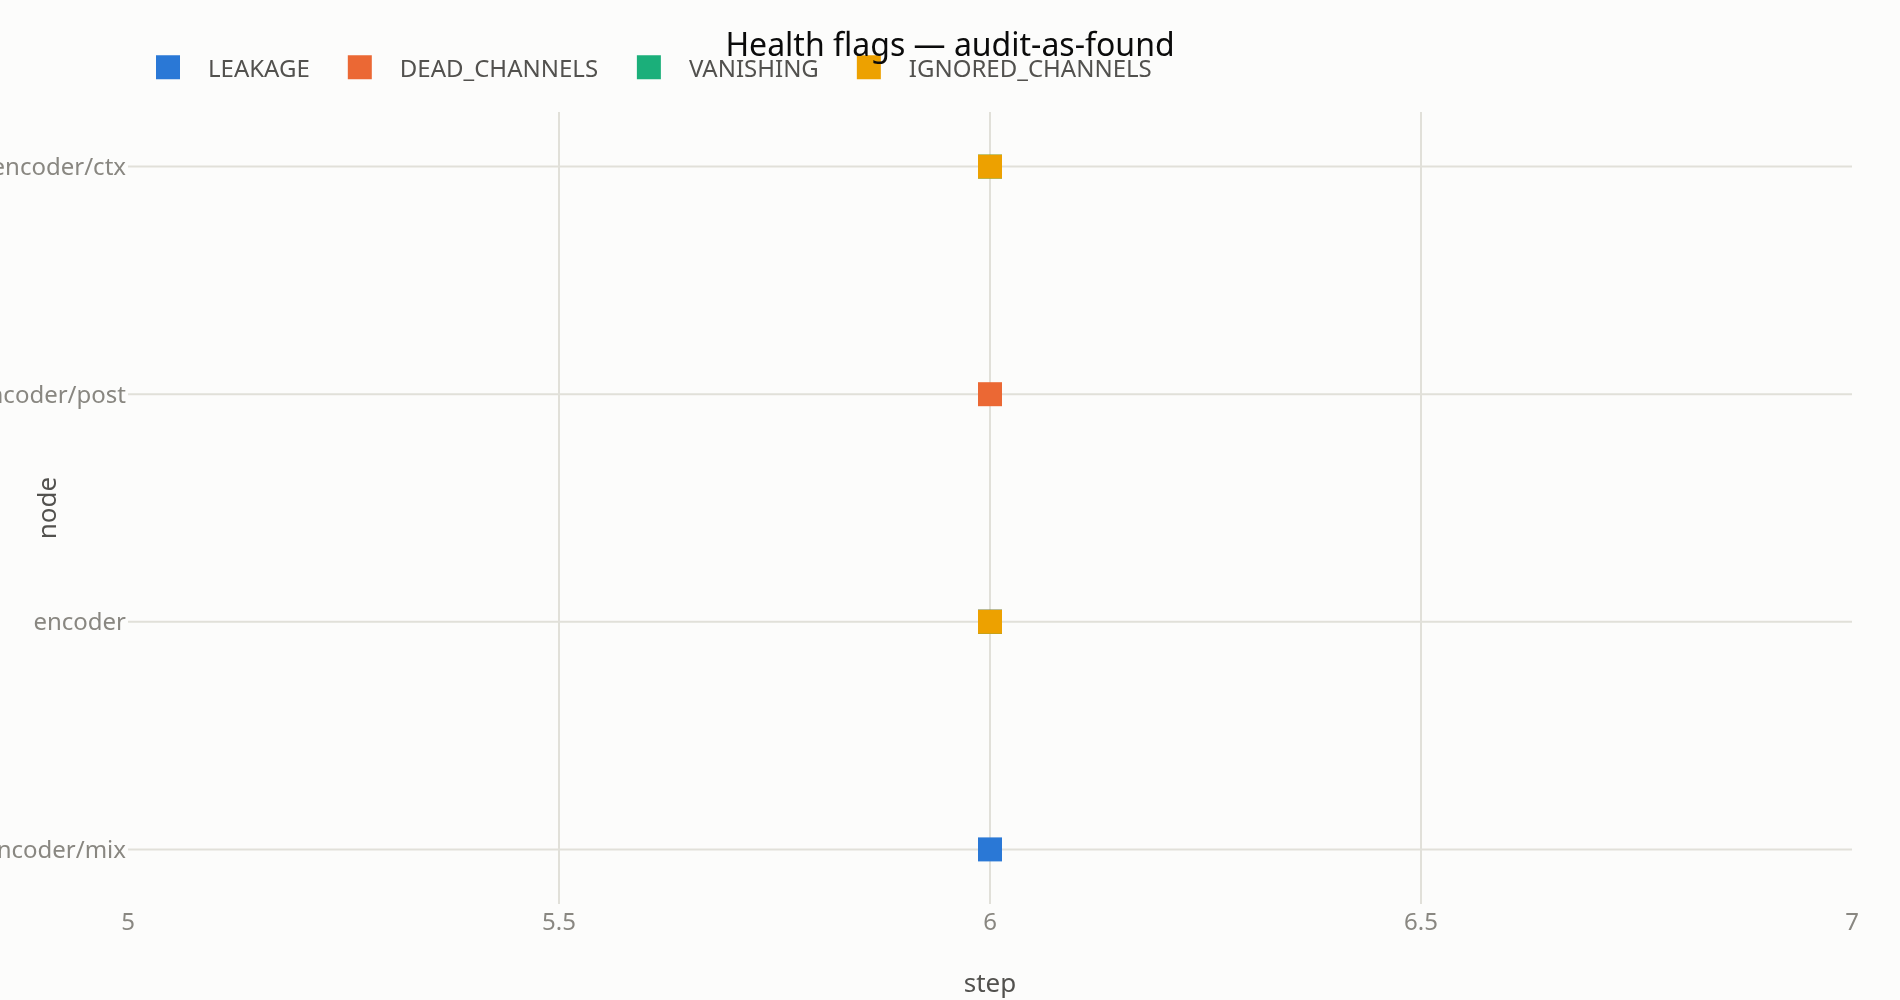

In [4]:
view = soma.RunView(run.dir)
view.plot_health()

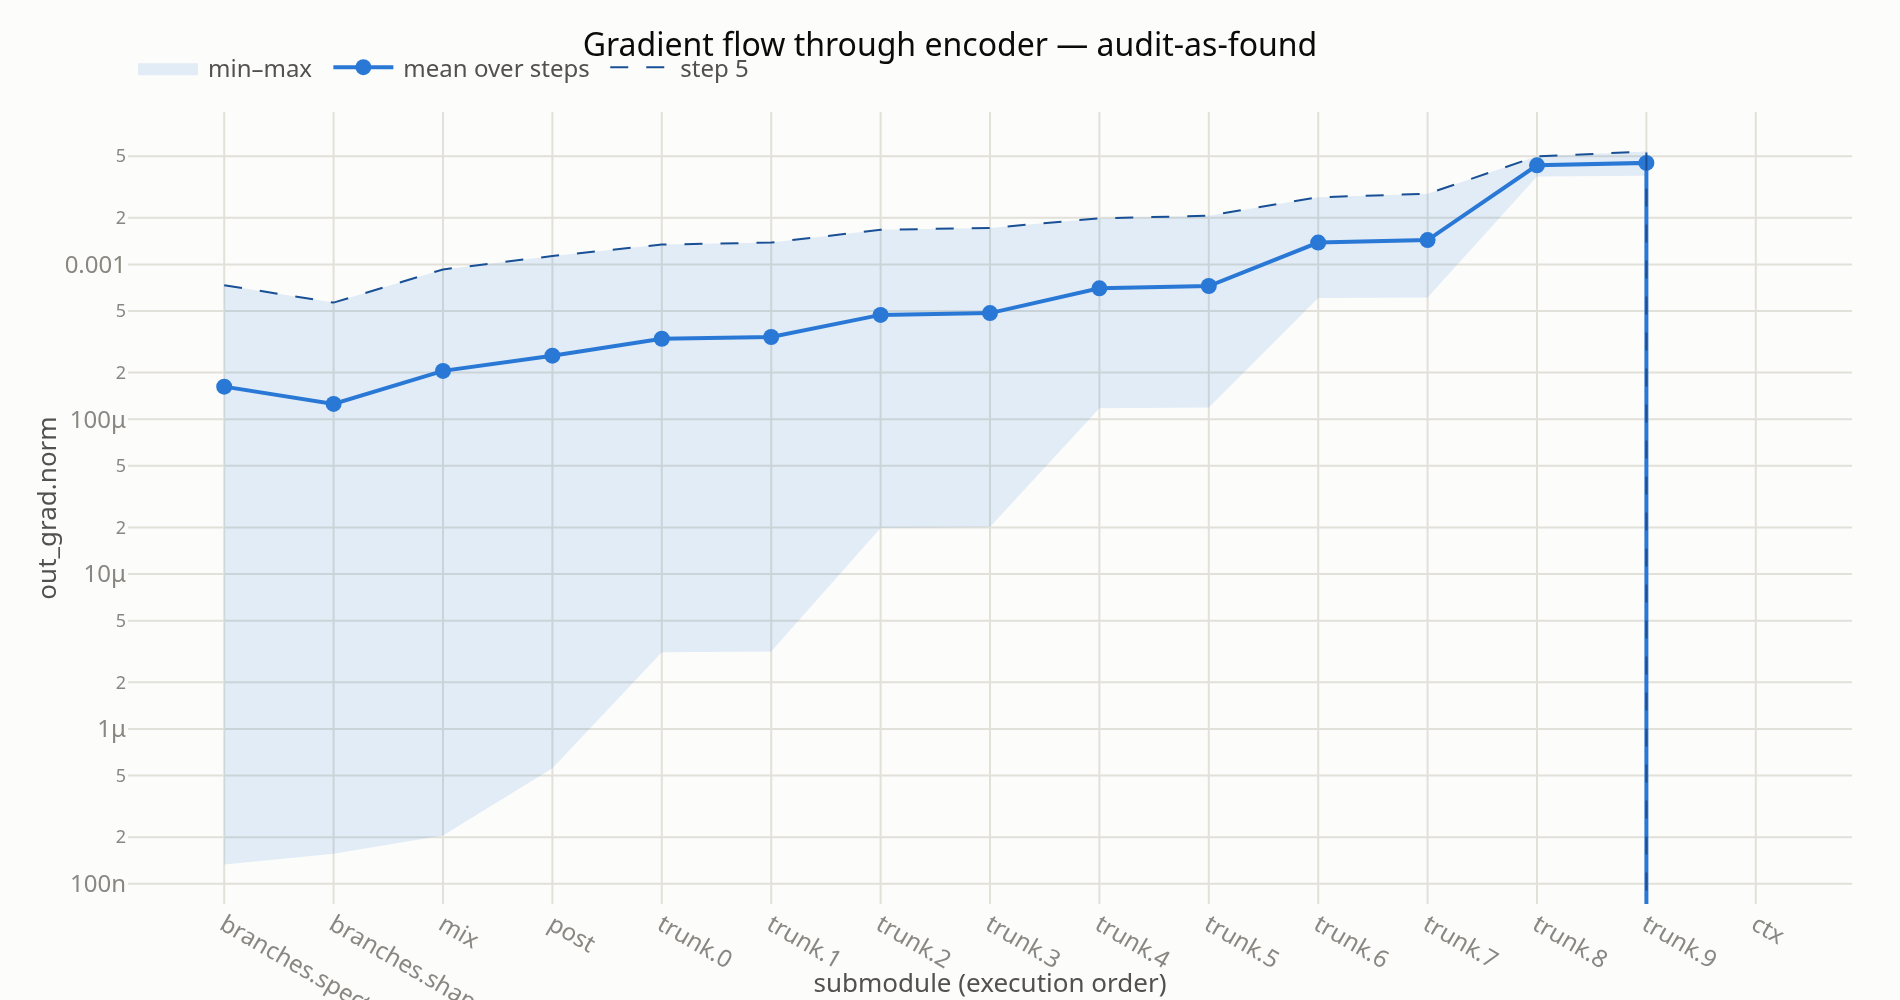

In [5]:
view.plot_module_flow("encoder")

That is the staircase: gradient norm shrinking layer by
layer toward the input. Whatever the first layers might have learned,
nothing reaches them to learn it with.

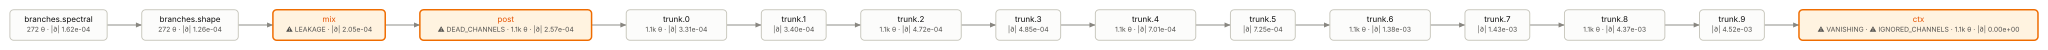

In [6]:
SVG(view.to_svg(node="encoder"))

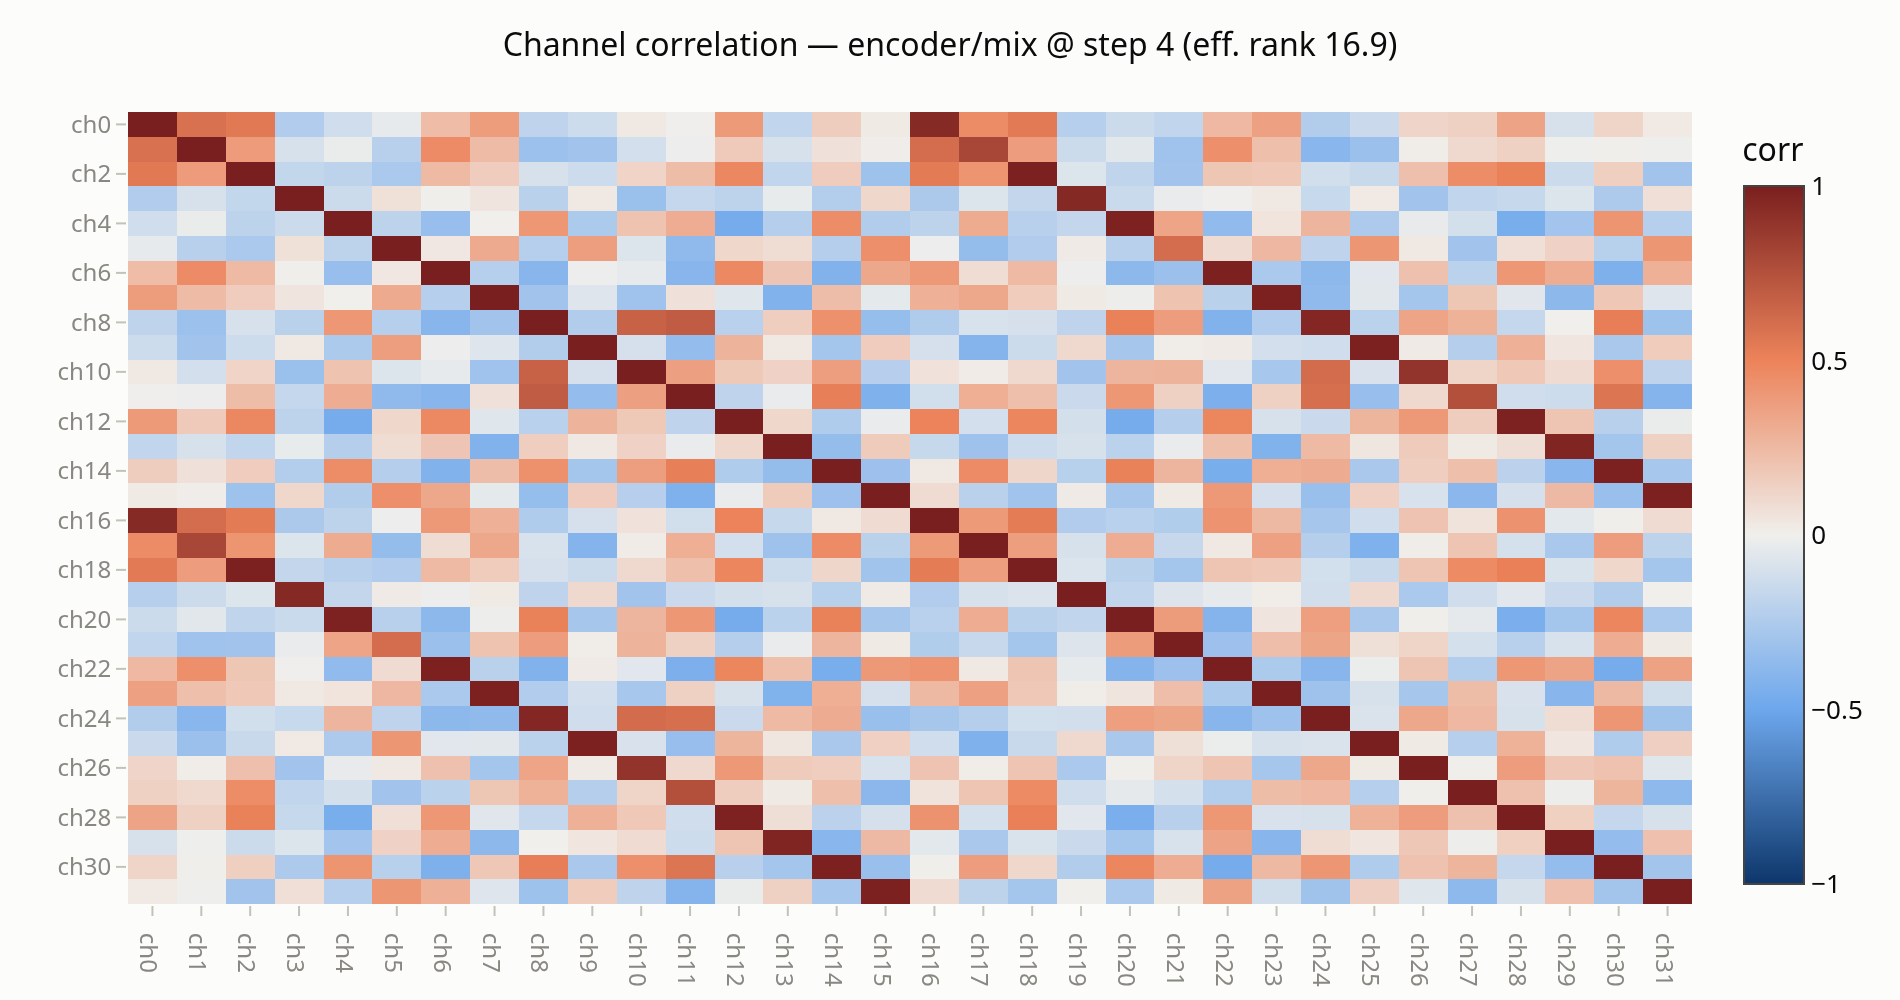

In [7]:
view.plot_channels("encoder/mix")

Channels 0–15 (spectral) and 16–31 (shape) have the same
profile, because they are computing the same thing from the same input.
Half the fusion layer's input is a duplicate.

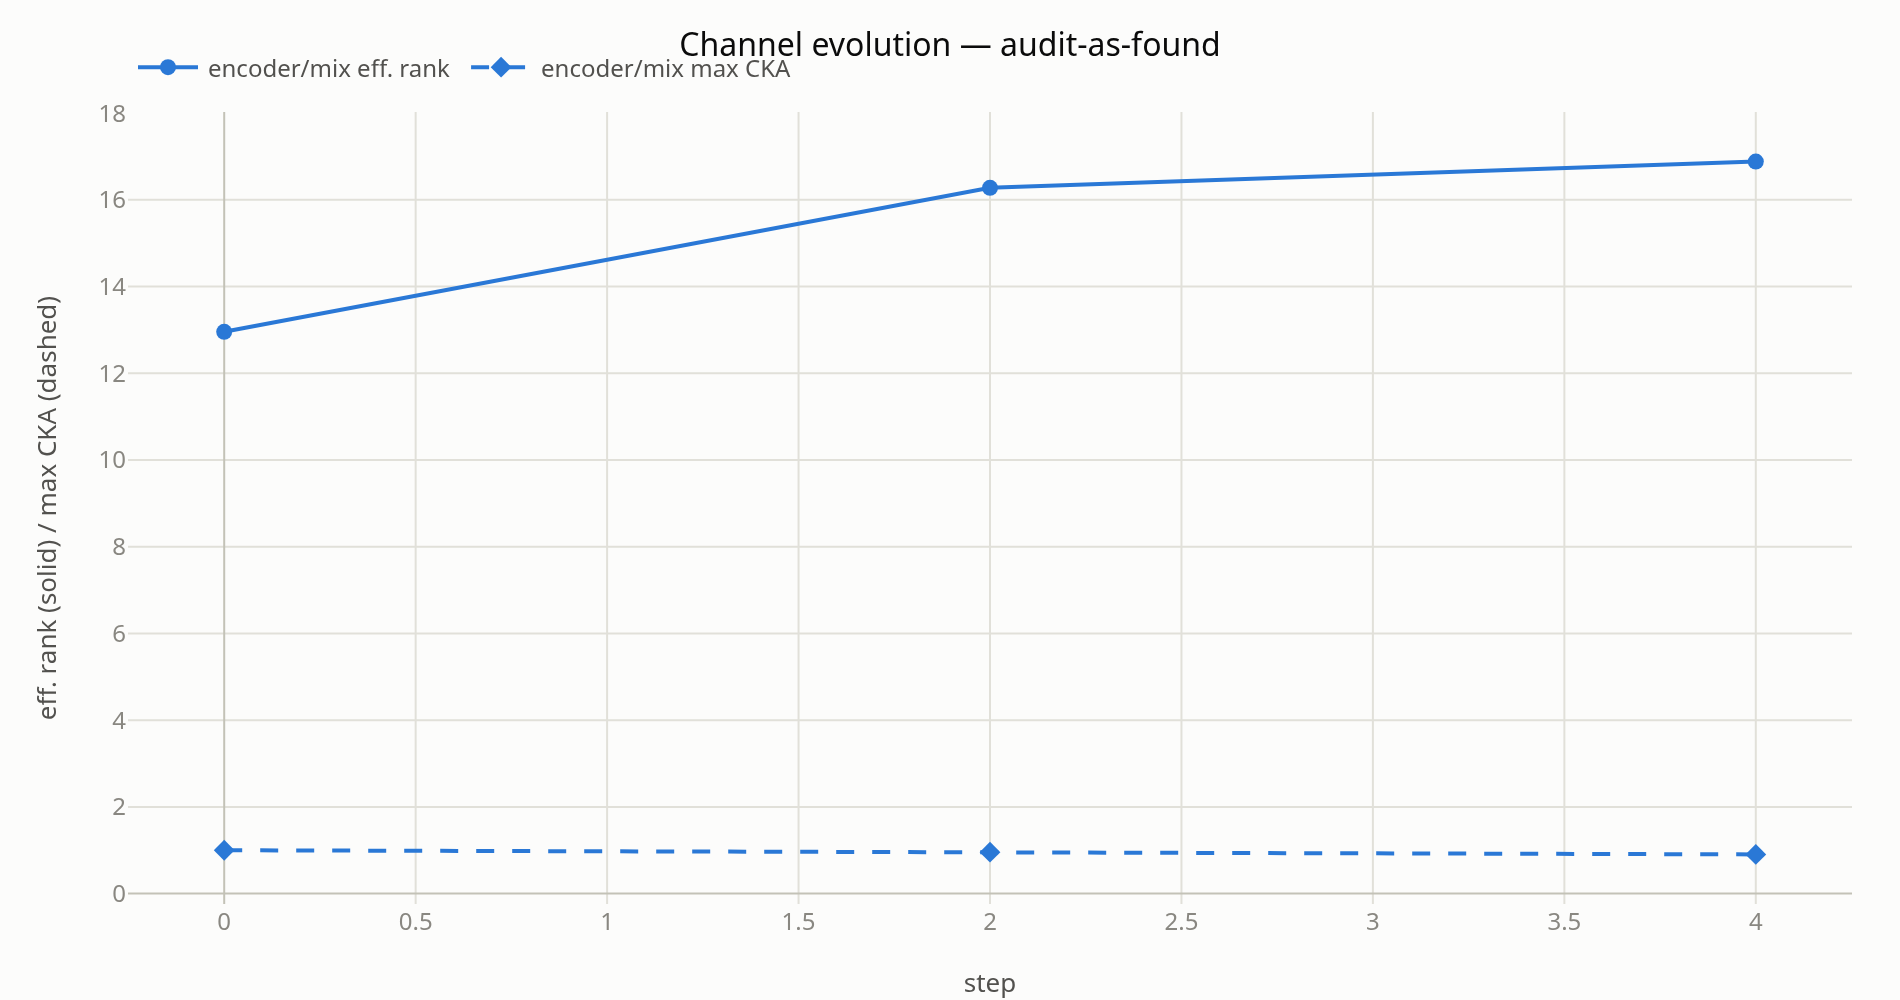

In [8]:
view.plot_channel_evolution("encoder/mix")

DEAD_CHANNELS          in: post
IGNORED_CHANNELS       in: ctx
LEAKAGE                in: mix
VANISHING              in: ctx


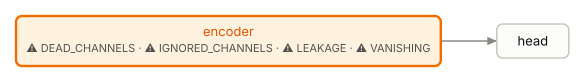

In [9]:
# The flags roll up to the outer graph, so the DAG shows
# you which node to look inside without parsing any ids.
for flag in view.health_flags():
    if flag["node_id"] == "encoder":
        print(f"{flag['flag']:22s} {flag['detail']}")
SVG(view.to_svg())

## 11.3 — Fix all four

Each fix is one switch. Whether each one *matters* is notebook 12's
question — here we just want an architecture worth tuning.

In [10]:
g_fixed = build(depth=5)   # every switch back to its healthy default
g_fixed.materialize(xtr)
g_fixed.train()
g_fixed.make_optimizer(torch.optim.Adam, lr=1e-2)

with g_fixed.track_run("audit-fixed", tags=["pulse-lab"]) as run_fixed:
    with g_fixed.gradient_audit(inside=inside, channels=channels) as audit_fixed:
        for step in range(6):
            with g_fixed.context() as ctx:
                g_fixed.zero_grad()
                out, _ = g_fixed.forward(xtr)
                g_fixed.backward(ctx, nn.functional.cross_entropy(out, ytr))
            g_fixed.step(ctx)

before = {f.filter_id: f.flags for f in audit.report().filters if f.flags}
after = {f.filter_id: f.flags for f in audit_fixed.report().filters if f.flags}
for node in sorted(set(before) | set(after)):
    print(f"{node:28s} {str(before.get(node, [])):46s} -> {after.get(node, [])}")

encoder/ctx                  ['VANISHING', 'IGNORED_CHANNELS(32)']          -> []
encoder/mix                  ['LEAKAGE']                                    -> []
encoder/post                 ['DEAD_CHANNELS(6)']                           -> ['DEAD_CHANNELS(1)']


LEAKAGE, IGNORED_CHANNELS and VANISHING are gone. One dead
channel remains, out of 32, which is ordinary ReLU attrition rather than
a planted fault — worth knowing about, not worth chasing.

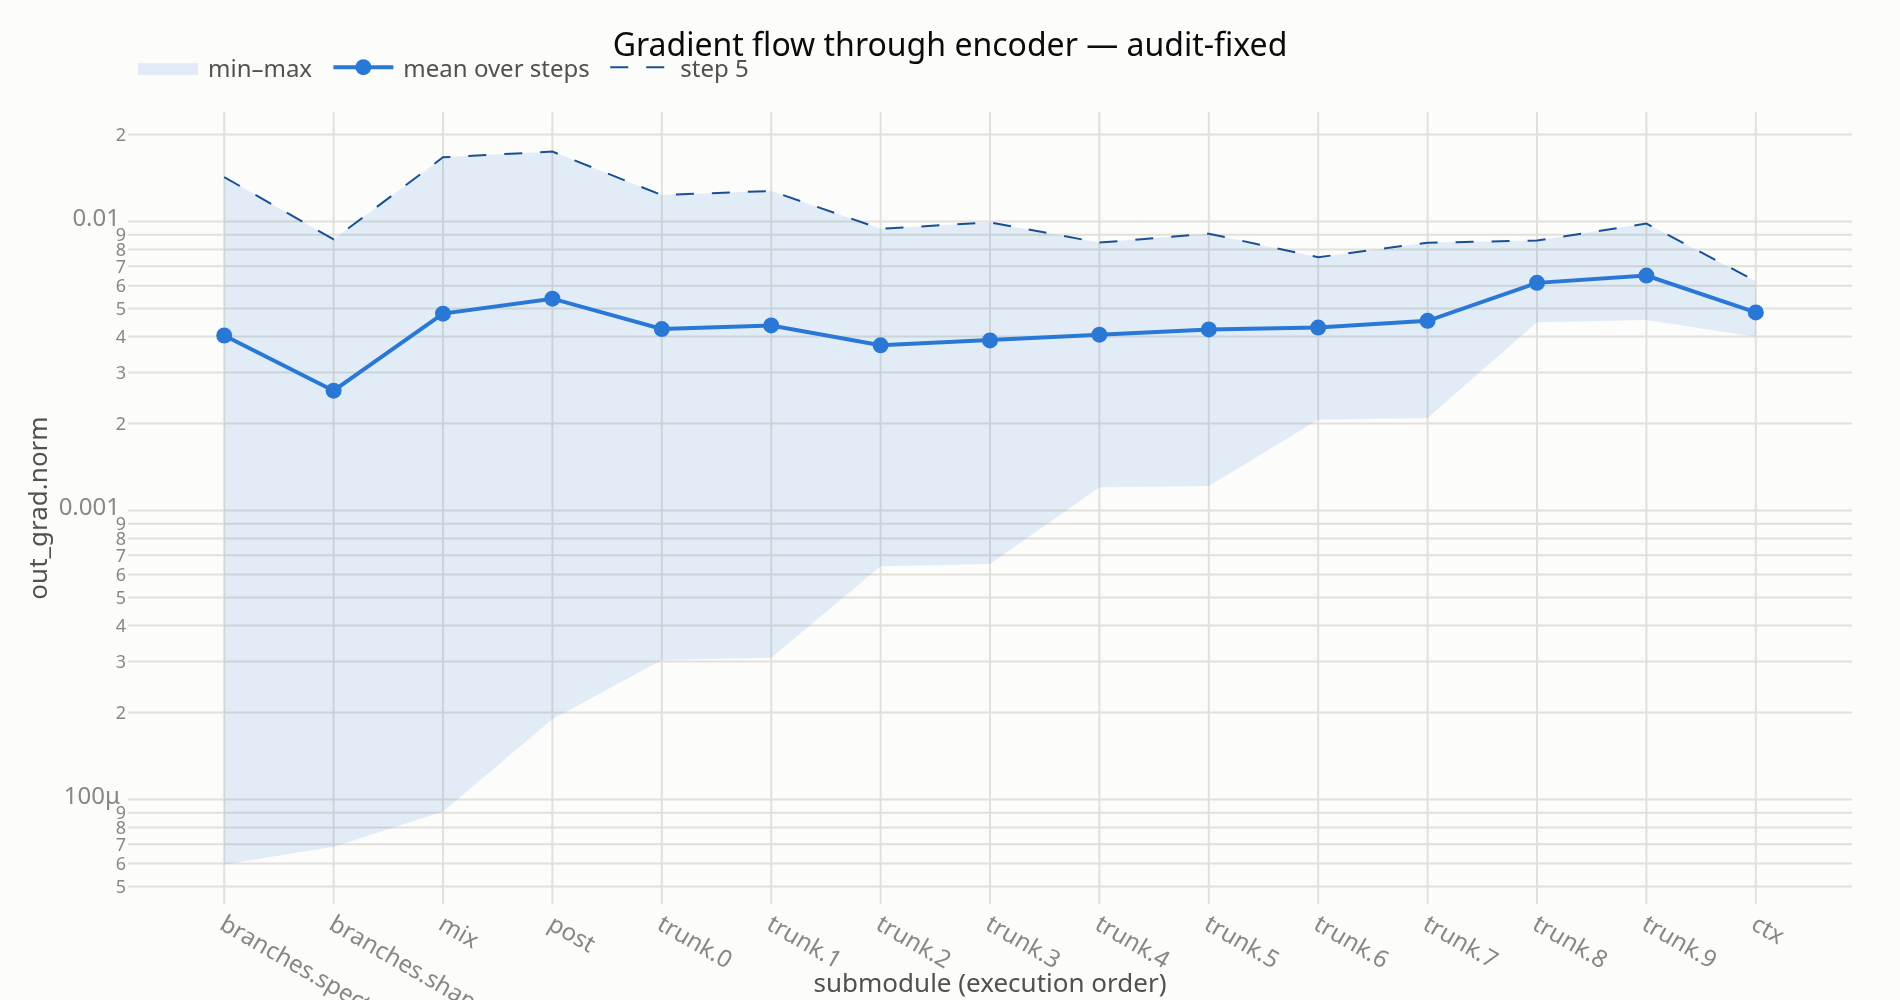

In [11]:
soma.RunView(run_fixed.dir).plot_module_flow("encoder")

Same axes as before. The profile is flat: gradient reaches
every layer.

## 11.4 — *Now* a sweep is worth running

One thing to know before reading the next cell: with `strategy="grid"`,
`n_trials` is the number of points **per dimension**, not the total. Two
dimensions at 3 points is 9 trials. A third dimension would make it 27.

In [12]:
search_space = [
    {"type": "float", "name": "lr", "low": 3e-3, "high": 3e-2, "scale": "log"},
    {"type": "int", "name": "head_hidden", "low": 8, "high": 24},
]

def objective(trial):
    torch.manual_seed(0)
    t = Graph()
    t.node("encoder", campaign.DualViewEncoder(depth=5))
    t.node("head", campaign.Head(hidden=trial["head_hidden"]))
    t.edge("encoder", "head")
    t.materialize(xtr)
    t.train()
    t.make_optimizer(torch.optim.Adam, lr=trial["lr"])

    for epoch in range(8):
        order = torch.randperm(384)
        for i in range(0, 384, 64):
            idx = order[i:i + 64]
            with t.context() as ctx:
                t.zero_grad()
                out, _ = t.forward(xtr[idx])
                t.backward(ctx, nn.functional.cross_entropy(out, ytr[idx]))
            t.step(ctx)
        t.eval()
        with torch.no_grad():
            acc = campaign.accuracy(np.asarray(t.forward(xva)), yva)
        t.train()
        if trial.report("val_acc", acc, epoch):   # True => pruned
            return None
    return {"val_acc": acc}

study = soma.Study(
    "pulse-grid",
    search_space=search_space,
    strategy="grid",
    n_trials=3,                      # per dimension: 3 x 3 = 9 trials
    objectives=[("val_acc", "maximize")],
    pruning=("median", 3),
    tags=["pulse-lab"],
)
study.run(objective)   # progress=True draws a tqdm bar in a live session
print("best:", study.best_trial["params"], "->", study.best_trial["metrics"])

best: {'head_hidden': 16, 'lr': 0.00948683298050514} -> {'val_acc': 0.984375}


In [13]:
soma.viz.trials_dataframe(study)

,trial_id,state,started_at,finished_at,duration_ms,param_head_hidden,param_lr,metric_val_acc
0,trial_0000,completed,2026-08-04 00:35:22.460765711+00:00,2026-08-04 00:35:22.755539679+00:00,294,8,0.003000,0.976562
1,trial_0001,completed,2026-08-04 00:35:22.755948716+00:00,2026-08-04 00:35:22.883858869+00:00,127,16,0.003000,0.984375
2,trial_0002,pruned,2026-08-04 00:35:22.884367084+00:00,2026-08-04 00:35:23.035128051+00:00,150,24,0.003000,0.968750
3,trial_0003,pruned,2026-08-04 00:35:23.035657944+00:00,2026-08-04 00:35:23.191253973+00:00,155,8,0.009487,0.968750
4,trial_0004,completed,2026-08-04 00:35:23.191891109+00:00,2026-08-04 00:35:23.349372683+00:00,157,16,0.009487,0.984375
5,trial_0005,pruned,2026-08-04 00:35:23.350409381+00:00,2026-08-04 00:35:23.455549429+00:00,105,24,0.009487,0.960938
6,trial_0006,pruned,2026-08-04 00:35:23.456552615+00:00,2026-08-04 00:35:23.533558184+00:00,76,8,0.030000,0.585938
7,trial_0007,pruned,2026-08-04 00:35:23.534465951+00:00,2026-08-04 00:35:23.604238409+00:00,69,16,0.030000,0.648438
8,trial_0008,pruned,2026-08-04 00:35:23.605153521+00:00,2026-08-04 00:35:23.688560814+00:00,83,24,0.030000,0.796875


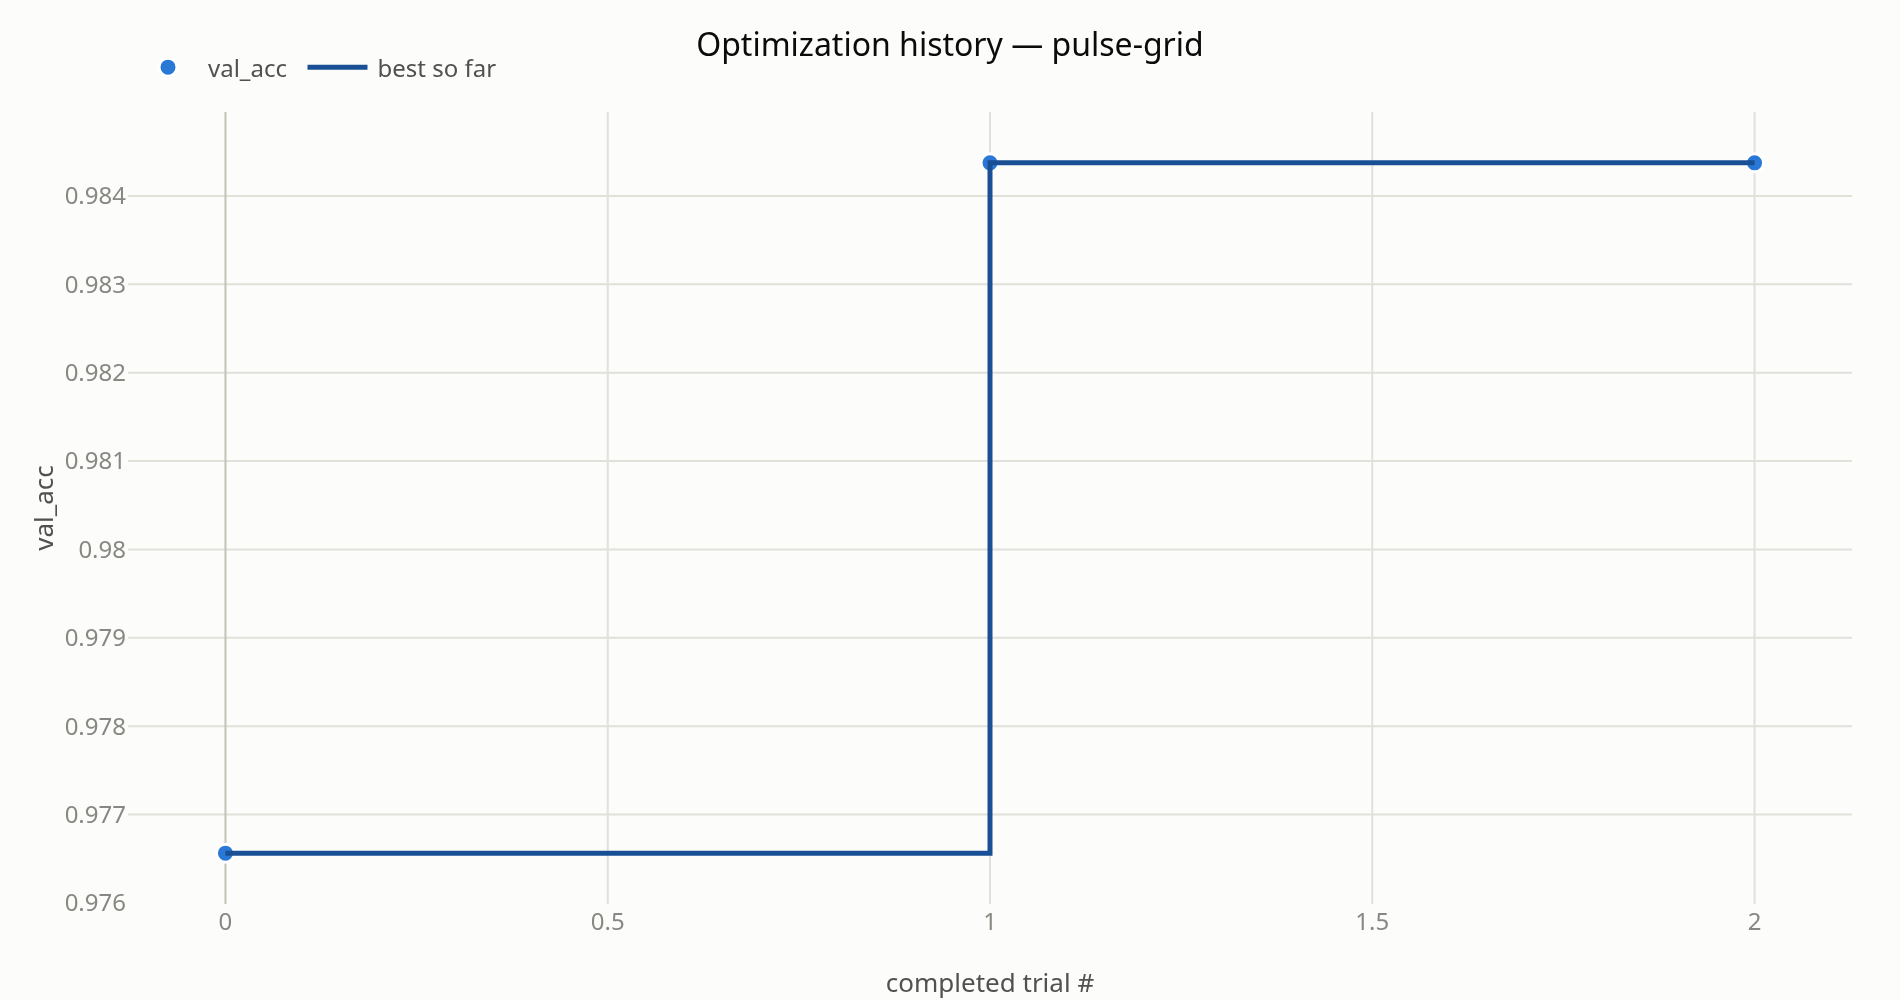

In [14]:
study.plot_optimization_history()

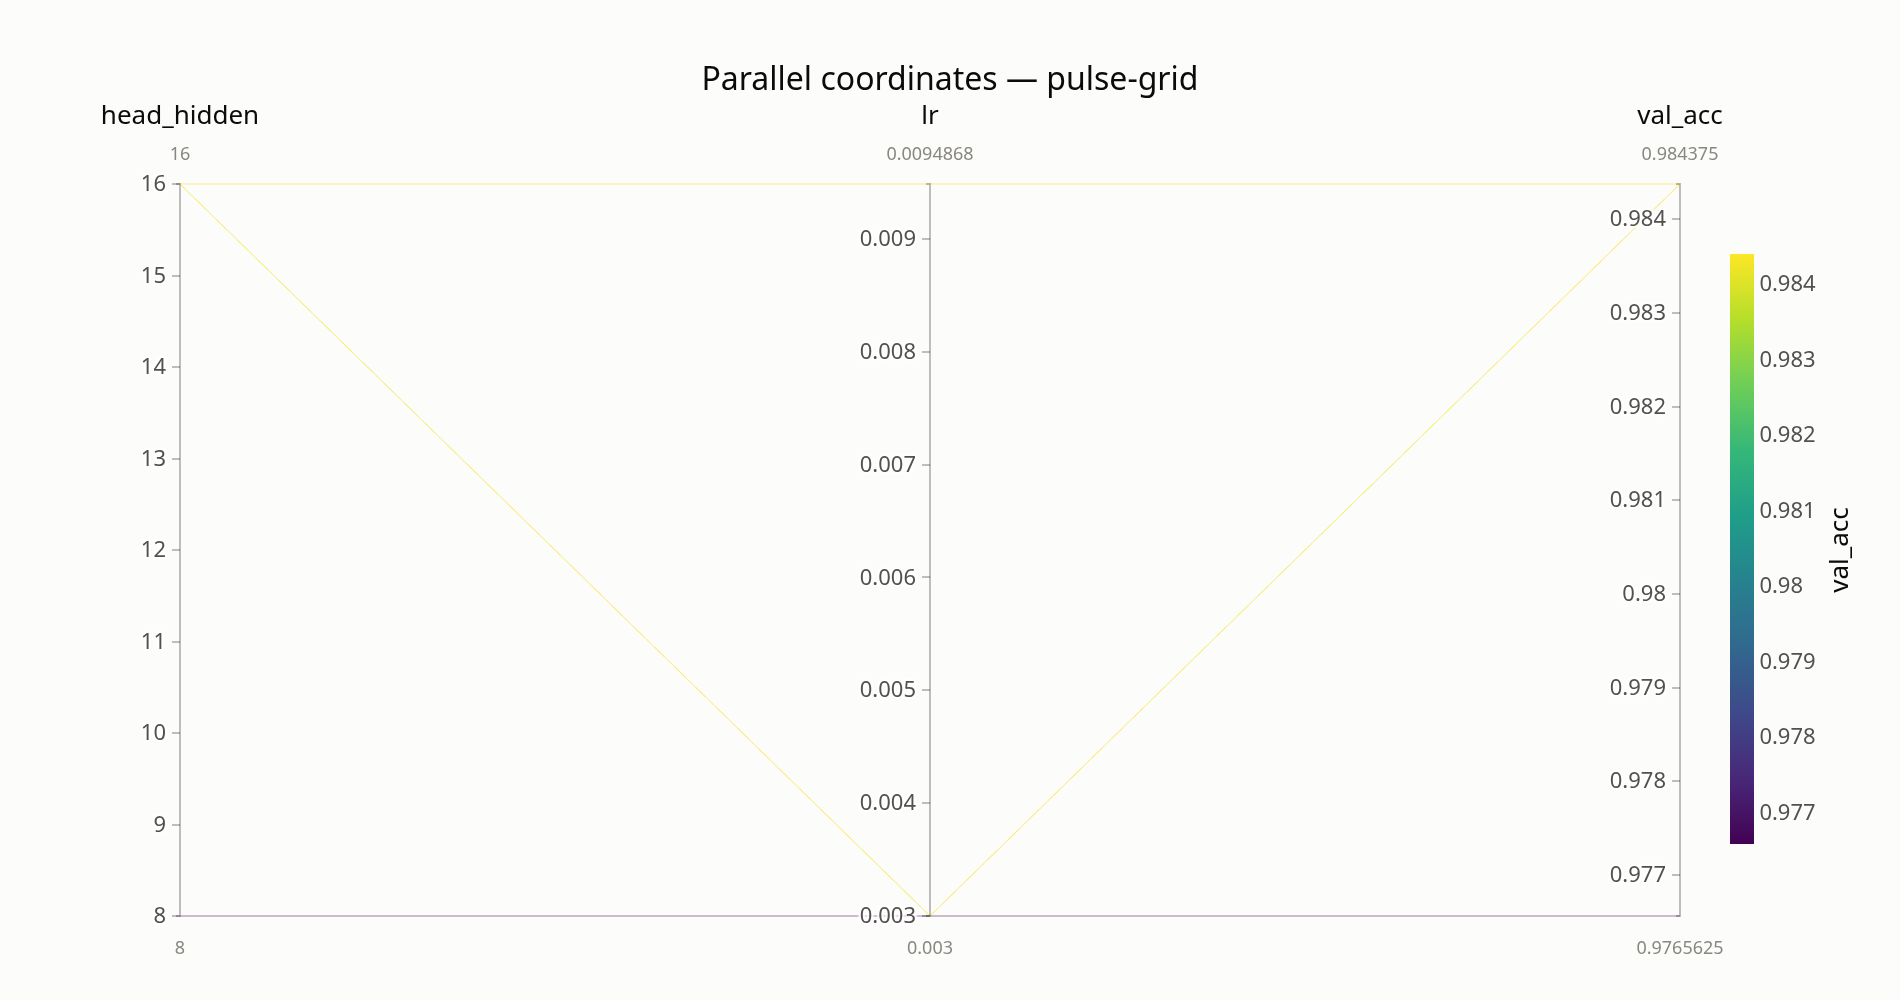

In [15]:
study.plot_parallel_coordinate()

## What's next

Fixing four things at once told us the model *can* be fixed. It did not
tell us **which** fix mattered — and notebook 12 shows that the answer
is not the one you would guess from this notebook.